# SE 2026 - Lab 1 (21/04/2026) : Indexing

We start today with the first component of an Information Retrieval system.

To perform the task of retrieving relevant documents for a given query, a search engine needs to know which documents are available and index them to efficiently retrieve them.

*Indexing loose definition: Creating a smart table of words and where (in which documents) they appear, just like a book index.*

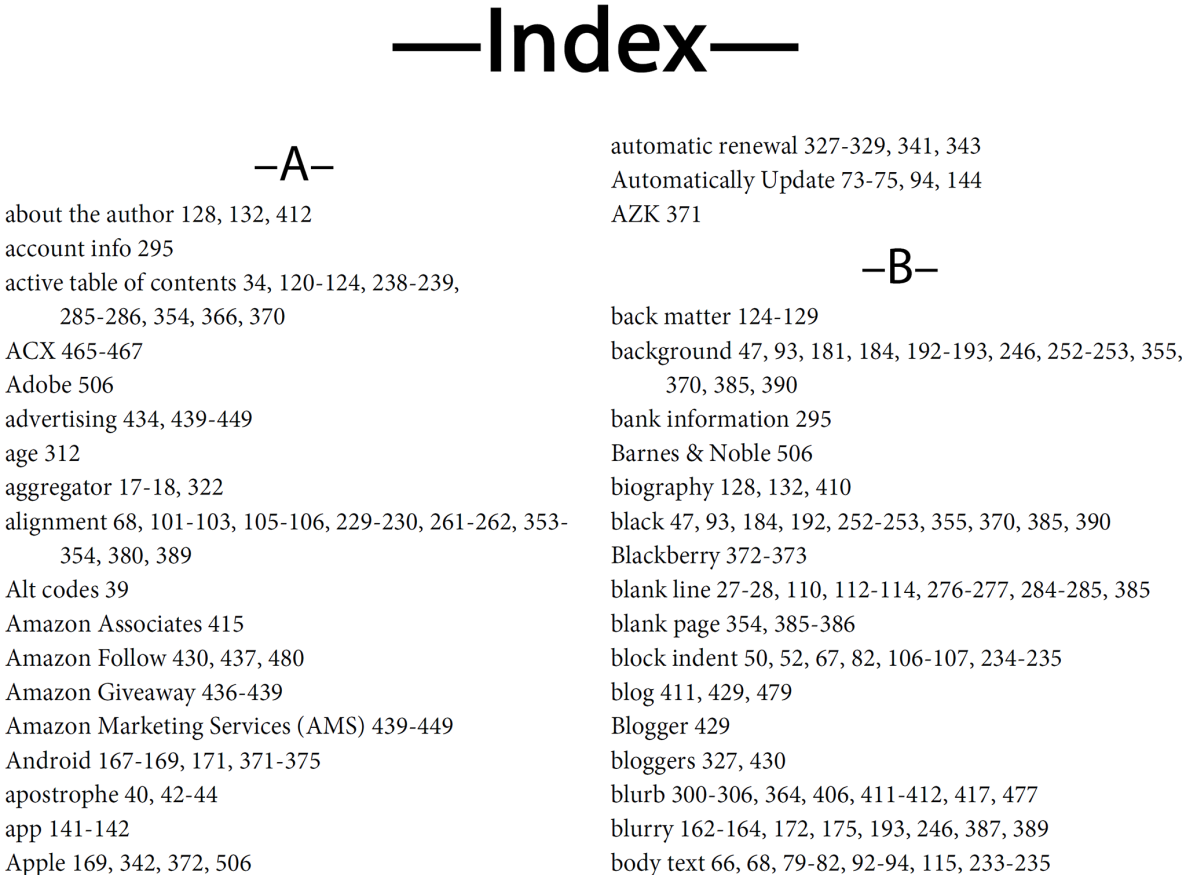

In [1]:
# install packages
%pip install numpy
%pip install pandas
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Top-level imports
import numpy as np
import pandas as pd
import seaborn as sns

## The dataset

First, we will introduce the dataset. In our labs, we will be using a subset of the small version of [WikIR](https://www.aclweb.org/anthology/2020.lrec-1.237.pdf) dataset for English.

Download the following files (available also on Absalon under folder `lab`) in a folder called `data/`:
- [`lab_docs.csv`](https://absalon.ku.dk/files/9458363/download?download_frd=1): CSV file of document number and document text
- [`lab_topics.csv`](https://absalon.ku.dk/courses/80617/files/9458357/download?download_frd=1): CSV file of query id and query text
- [`lab_qrels.csv`](https://absalon.ku.dk/files/9458364/download?download_frd=1): CSV file of annotations with schema `qid, docno, label, iteration`

In [13]:
docs = pd.read_csv('/home/tlvj/msc_datalogi/2_semester/se/lab_test/lab_docs.csv', dtype={'docno': str})
topics = pd.read_csv('/home/tlvj/msc_datalogi/2_semester/se/lab_test/lab_topics.csv')
qrels = pd.read_csv('/home/tlvj/msc_datalogi/2_semester/se/lab_test/lab_qrels.csv') # qrels signify the ground truth

In [14]:
print(docs.shape)
docs.sample(5, random_state=42)

(2453, 2)


,docno,text
2115,941063,during his apprenticeship baumeister also bega...
700,2409254,the panzerwurfk rper 42 was designed to be fir...
1165,777997,born in shelbyville illinois caldwell was a pr...
2417,1186821,she is of basque descent larra n currently sit...
1626,1257567,the brigade served in the east african campaig...


In [15]:
print(docs['text'].iloc[2115])

during his apprenticeship baumeister also began art studies at the stuttgart art academy k niglich w rttembergische akademie 1905 1906 attended robert poetzelberger s drawing class and took additional lessons from josef kerschensteiner in 1906 he resumed his apprenticeship and in 1907 completed the trade test following his military service baumeister continued his studies at the art academy dismissed by his teacher poetzelberger due to lack of talent he switched into the composition class of adolf h lzel with whom he studied until 1912 where he met his lifelong friend oskar schlemmer baumeister took his first trip to paris in 1911 successfully participated in a gallery exhibition in zurich in 1912 and a year later participated in der erste deutsche herbstsalon the first german autumn salon in the berlin gallery der sturm there he met the expressionist painter franz marc in 1914 baumeister had his first solo exhibition at der neue kunstsalon new art salon in stuttgart in the same year a

In [28]:
print(topics.shape)
topics.sample(9)

(9, 2)


,qid,query
2,340095,2020 summer olympics
4,2574,chinese cuisine
8,8438,mexican cuisine
1,2674,computer animation
0,1015979,president of chile
5,14082,world war ii
3,1502917,train station
6,1250390,painting
7,5597,house


In [17]:
print(qrels.shape)
qrels.sample(5)

(2454, 4)


,qid,docno,label,iteration
445,14082,864885,1,0
962,14082,2197280,1,0
291,14082,719386,1,0
1083,14082,1188695,1,0
414,14082,1592271,1,0


*What is label in qrels table?*

*Label = 2 implies highly relevant document, Label = 1 implies somewhat relevant doc for the qid*


In [18]:
print("Unique labels: \n", qrels['label'].unique())
print("\n")
print("Distribution of labels: \n", qrels[['qid','label']].groupby(by='label').count().reset_index())

Unique labels: 
 [2 1]


Distribution of labels: 
    label   qid
0      1  2445
1      2     9


*Let's have a look at a highly relevant document*

In [19]:
print(qrels[qrels['label']==2])

          qid    docno  label  iteration
0     1015979  1015979      2          0
7      340095   340095      2          0
29    1502917  1502917      2          0
47       2574     2574      2          0
63       2674     2674      2          0
106      8438     8438      2          0
116     14082    14082      2          0
2150  1250390  1250390      2          0
2447     5597     5597      2          0


In [20]:
print(qrels[qrels['qid']==1015979])
# Sneak peak into the query for qid 1015979
print("\nQuery")
print(topics[topics['qid']==1015979]['query'].iloc[0])
# Sneak peak into document highly relevant for qid 1015979
print("\nHighly relevant text for qid 1015979")
print(docs[docs['docno']=='1015979']['text'].iloc[0])
# Sneak peak into document somwwhat relevant for qid 1015979
print("\nSomewhat relevant text for qid 1015979")
print(docs[docs['docno']=='2226456']['text'].iloc[0])


       qid    docno  label  iteration
0  1015979  1015979      2          0
1  1015979  2226456      1          0
2  1015979  1514612      1          0
3  1015979  1119171      1          0
4  1015979  1053174      1          0
5  1015979  1186821      1          0
6  1015979   229754      1          0

Query
president of chile

Highly relevant text for qid 1015979
the president is responsible for both the chilean government and state administration although its role and significance has changed over the history of chile as well as its position and relations with other actors in the national political organization it is one of the most prominent political figures it is also considered as one of the institutions that make up the historic constitution of chile and is essential to the country s political stability under the current constitution adopted in 1980 the president serves a four year term with immediate re election being prohibited the shorter period previously the term was six y

*What is iteration in qrels table?*

*Iteration tracks which iteration or phase of relevance feedback the entry belongs to. For example:*

*Iteration 0: Initial set of relevance judgments, often used to train the first retrieval model.*

*Iteration 1, 2, ...: Subsequent rounds where users or a system provide new feedback, and the model updates.*

*We will cover this in week 20*

In [21]:
qrels['iteration'].unique()

array([0])

We can extract some simple statistics from this dataset:


In [22]:
# Counting the number of characters as doc_len
docs['doc_len'] = docs['text'].map(len)
docs['doc_len'].describe()

count    2453.000000
mean     1137.236038
std        79.567254
min       295.000000
25%      1106.000000
50%      1143.000000
75%      1181.000000
max      1354.000000
Name: doc_len, dtype: float64

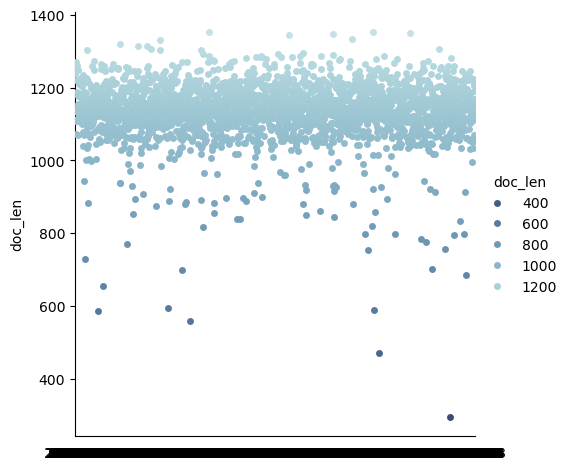

In [23]:
ax = sns.catplot(docs, x='docno', y='doc_len', hue='doc_len', palette="ch:r=-.2,d=.3_r")
ax.tick_params(bottom=False)
ax.set(xlabel=None)

## Indexing with Python

There exist several software libraries that can help you develop a search engine.
They usually provide highly optimized indexes, scoring algorithms (e.g. BM25) and other features such as text pre-processing.

Popular libraries include:
- [INDRI](https://www.lemurproject.org/indri/)
- [Elasticsearch](https://github.com/elastic/elasticsearch)
- [Anserini](https://github.com/castorini/anserini)
- [Terrier](https://github.com/terrier-org/terrier-core)
- [Whoosh](https://pypi.org/project/Whoosh/)

As Python is becoming the standard programming language in Data Science and Deep Learning, Python interfaces have been added to several libraries:
- [Elasticsearch-py](https://github.com/elastic/elasticsearch-py) for Elasticsearch
- [Pyserini](https://github.com/castorini/pyserini/) for Anserini
- [Py-Terrier](https://github.com/terrier-org/pyterrier) for Terrier
- [BEIR](https://github.com/beir-cellar/beir.git) for BEIR

In our labs we will show how to build an IR system using PyTerrier:

- [Py-Terrier](https://github.com/terrier-org/pyterrier)


Underneath these libraries use Java, so you need to have at least Java 11. Below we show you how to install it on Colab/Kaggle but you can refer to several tutorials to help in this task, such as [this one for Linux](https://computingforgeeks.com/how-to-install-java-11-on-ubuntu-debian-linux/) and [this one for macOS](https://mkyong.com/java/how-to-install-java-on-mac-osx/).

In [24]:
!curl -s "https://get.sdkman.io" | bash && source "$HOME/.sdkman/bin/sdkman-init.sh" && sdk install java 11.0.22-amzn < /dev/null


                                -+syyyyyyys:
                            `/yho:`       -yd.
                         `/yh/`             +m.
                       .oho.                 hy                          .`
                     .sh/`                   :N`                `-/o`  `+dyyo:.
                   .yh:`                     `M-          `-/osysoym  :hs` `-+sys:      hhyssssssssy+
                 .sh:`                       `N:          ms/-``  yy.yh-      -hy.    `.N-````````+N.
               `od/`                         `N-       -/oM-      ddd+`     `sd:     hNNm        -N:
              :do`                           .M.       dMMM-     `ms.      /d+`     `NMMs       `do
            .yy-                             :N`    ```mMMM.      -      -hy.       /MMM:       yh
          `+d+`           `:/oo/`       `-/osyh/ossssssdNMM`           .sh:         yMMN`      /m.
         -dh-           :ymNMMMMy  `-/shmNm-`:N/-.``   `.sN            /N-         `NMMy      .m/
  

In [25]:
!java --version
!javac --version

openjdk 11.0.22 2024-01-16 LTS
OpenJDK Runtime Environment Corretto-11.0.22.7.1 (build 11.0.22+7-LTS)
OpenJDK 64-Bit Server VM Corretto-11.0.22.7.1 (build 11.0.22+7-LTS, mixed mode)
javac 11.0.22


## PyTerrier

In [20]:
%%capture
!pip install python-terrier

In [ ]:
# !echo $JAVA_HOME
# !which java
# !readlink -f $(which java)
# !find /usr/lib/jvm -name libjvm.so 2>/dev/null

/root/.sdkman/candidates/java/current
/usr/bin/java
/usr/lib/jvm/java-25-openjdk-amd64/bin/java
/usr/lib/jvm/java-11-openjdk-amd64/lib/server/libjvm.so
/usr/lib/jvm/java-25-openjdk-amd64/lib/server/libjvm.so


To use PyTerrier, we need to both import it and initialize it.
The initialization with the `init()` method makes PyTerrier download Terrier's JAR file as well as start the Java virtual machine.
To avoid `init()` being called more than once, we can check if it's being initialized through the `started()` method.

In [27]:
%env JAVA_HOME=/usr/lib/jvm/java-11-openjdk-amd64
%env JVM_PATH=/usr/lib/jvm/java-11-openjdk-amd64/lib/server/libjvm.so

import pyterrier as pt
if not pt.started():
    pt.init()

env: JAVA_HOME=/usr/lib/jvm/java-11-openjdk-amd64
env: JVM_PATH=/usr/lib/jvm/java-11-openjdk-amd64/lib/server/libjvm.so


/tmp/ipykernel_6381/3773262781.py:5: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():
Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_6381/3773262781.py:6: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


In PyTerrier, we can create an index from a Pandas DataFrame with the `IterDictIndexer` method.
The index, with all its data structures, is written into a directory called `indexes/default`.

In [28]:
indexer = pt.IterDictIndexer("./indexes/default", overwrite=True)
index_ref = indexer.index(docs.to_dict(orient='records'))
index_ref.toString()

'./indexes/default/data.properties'

The returned `IndexRef` is basically a string saying where an index is stored.
A PyTerrier index contains several files:

The preferred way to index in PyTerrier is the

In [29]:
!ls -lh indexes/default

total 2.9M
-rw-r--r-- 1 tlvj tlvj 271K Apr 21 14:03 data.direct.bf
-rw-r--r-- 1 tlvj tlvj  41K Apr 21 14:03 data.document.fsarrayfile
-rw-r--r-- 1 tlvj tlvj 281K Apr 21 14:03 data.inverted.bf
-rw-r--r-- 1 tlvj tlvj 2.0M Apr 21 14:03 data.lexicon.fsomapfile
-rw-r--r-- 1 tlvj tlvj 1017 Apr 21 14:03 data.lexicon.fsomaphash
-rw-r--r-- 1 tlvj tlvj  93K Apr 21 14:03 data.lexicon.fsomapid
-rw-r--r-- 1 tlvj tlvj 156K Apr 21 14:03 data.meta-0.fsomapfile
-rw-r--r-- 1 tlvj tlvj  20K Apr 21 14:03 data.meta.idx
-rw-r--r-- 1 tlvj tlvj  55K Apr 21 14:03 data.meta.zdata
-rw-r--r-- 1 tlvj tlvj 4.2K Apr 21 14:03 data.properties


These files represent several data structures:
- Lexicon: Records the list of all unique terms and their statistics
- Document index: Records the statistics of all documents (e.g. document length)
- Inverted index: Records the mapping between terms and documents
- Meta index: Records document metadata (e.g. document number, URL, raw text, etc passed through `indexer.index()`)
- Direct index: Records terms for each document

Once we have an `IndexRef`, we can load it to an actual index:

In [30]:
index = pt.IndexFactory.of(index_ref)

# lets see what type index is
type(index)

jnius.reflect.org.terrier.structures.Index

Ok, so this object refers to Terrier's [`Index`](http://terrier.org/docs/current/javadoc/org/terrier/structures/Index.html) type.

Looking at the linked Javadoc, we can see that this Java object has methods such as:
 - `getCollectionStatistics()`
 - `getInvertedIndex()`
 - `getLexicon()`

Let's see what is returned by the `CollectionStatistics()` method:

In [31]:
print(index.getCollectionStatistics().toString())

Number of documents: 2453
Number of terms: 23693
Number of postings: 208487
Number of fields: 0
Number of tokens: 273373
Field names: []
Positions:   false



* `Number of documents (N)`: Total number of items (docs/rows) in your dataset.
* `Number of terms (|V|)`: This is the size of your Vocabulary. It counts how many unique words exist in the entire index after text processing (like removing punctuation or converting to lowercase).  
* `Number of postings`: A posting is a single record within an inverted index that maps a term (word, feature) to a specific document in which it appears. This is number is the sum of all the posting. Essentially, count of unique word-document pairs.
* `Number of tokens`: Total number of words. The sum of every word in the original documents.
* `Field Names`: Fields are specific "zones" within a document. If data has a Title, a Body, and a URL, these are 3 fields.
* `Positions`: This is a boolean (True/False) flag indicating if the index stores where each word is located in a sentence.

### Sample Example


`Doc1`: "blue fish red fish"

`Doc2`: "blue cat"

`Number of documents`: 2

`Number of terms`: 4 (blue, fish, red, cat)

`Number of tokens`: 6 (4 + 2)

`Number of postings`: 2 (blue in doc1 and doc2) + 1 (fish in doc1) + 1 (red in doc1) + 1 (cat in doc2) = 5

In [32]:
# Index starts from 0th document to 2452th document
print(index.getEnd())
print(index.getStart())

2452
0


In [33]:
# Retrieve the length (in tokens/terms) of the document with internal document ID 1 from PyTerrier index.
index.getDocumentIndex().getDocumentLength(1)

106

In [34]:
# Let's verify

# get the docno of the document ID 1
meta = index.getMetaIndex().getItem("docno", 1)
print("Document ID:", meta)

Document ID: 2360440


In [35]:
# get the corresponding text
text = docs[docs['docno']=='2360440']['text'].iloc[0]

# check the number of words
len(text.split())


200

***Question: Why does it differ?***

In [36]:
# Retrieve all metadata values for the document with internal docid 1
index.getMetaIndex().getAllItems(1)

['2360440']

### Lexicon

What is our vocabulary of terms?

This is the [Lexicon](http://terrier.org/docs/current/javadoc/org/terrier/structures/Lexicon.html), which can be iterated easily from Python:

In [37]:
# Retrieve term statistics appearing in indices (1900, 1905)
ix_range = range(1900, 1905)
for ix, kv in enumerate(index.getLexicon()):
    if ix in ix_range:
        print(f"{kv.getKey()} -> {kv.getValue().toString()}")
    elif ix > ix_range[-1]:
        break

agenda -> term9700 Nt=3 TF=3 maxTF=1 @{0 30035 3}
agent -> term17 Nt=40 TF=51 maxTF=3 @{0 30042 1}
aggi -> term9651 Nt=1 TF=1 maxTF=1 @{0 30099 6}
aggrav -> term18279 Nt=2 TF=2 maxTF=1 @{0 30102 2}
aggreg -> term9189 Nt=3 TF=3 maxTF=1 @{0 30107 4}


Here, iterating over the Lexicon returns a pair of String term and a [LexiconEntry](http://terrier.org/docs/current/javadoc/org/terrier/structures/LexiconEntry.html) object – which itself is an [EntryStatistics](http://terrier.org/docs/current/javadoc/org/terrier/structures/EntryStatistics.html) – and contains information including the statistics of that term:
- `Nt` is the is the number of unique documents that each term occurs in (this is useful for calculating IDF)
- `TF` is the total number of occurrences – some weighting models use this instead of Nt
- The numbers in the `@{}` are pointers for Terrier to find that term in the inverted index on disk

### Inverted Index

The inverted index tells us in which _documents_ each term occurs.

`Index` - Map of documents to terms

`Inverted Index` - Map of terms to documents

The LexiconEntry is also the pointer to find the postings (i.e. occurrences) for that term in the inverted index.


In [38]:
# Where does 'agenda' appear?
pointer = index.getLexicon()["agenda"]
print("Pointer: ", pointer)
for posting in index.getInvertedIndex().getPostings(pointer):
    print(f"{posting.toString()} doclen={posting.getDocumentLength()}")

Pointer:  term9700 Nt=3 TF=3 maxTF=1 @{0 30035 3}
ID(520) TF(1) doclen=117
ID(709) TF(1) doclen=112
ID(1052) TF(1) doclen=107


Ok, so we can see that `"agenda"` occurs once in documents with ids 520, 709 and 1052.

Note that these are internal document ids of Terrier.
We can know which documents (i.e. the string "docno" in the corpus DataFrame) from the metaindex:

### Text Pre-processing

Looking at the terms in the Lexicon, do you think the index applied any text pre-processing?

What happens if we lookup a very frequent term?

In [39]:
index.getLexicon()["agenda"].toString()

'term9700 Nt=3 TF=3 maxTF=1 @{0 30035 3}'

Indeed, Terrier removes standard stopwords and applies Porter's stemmer by default.

### Index Variants

We can modify the pre-processing transformations applied by Terrier when creating an index by changing its `term pipelines` property.

In [42]:
# No pre-processing
indexer = pt.IterDictIndexer("./indexes/none", overwrite=True, stopwords=None, stemmer=None)
index_ref = indexer.index(docs.to_dict(orient='records'))
index = pt.IndexFactory.of(index_ref)
print(index.getCollectionStatistics().toString())

index.getLexicon()["the"].toString()

Number of documents: 2453
Number of terms: 30772
Number of postings: 292376
Number of fields: 0
Number of tokens: 485085
Field names: []
Positions:   false



'term74 Nt=2453 TF=36293 maxTF=34 @{0 333300 3}'

In [44]:
# Stopwords removal
indexer = pt.IterDictIndexer("./indexes/stopwords", overwrite=True, stopwords='terrier', stemmer=None)
index_ref = indexer.index(docs.to_dict(orient='records'))
index = pt.IndexFactory.of(index_ref)
print(index.getCollectionStatistics().toString())

Number of documents: 2453
Number of terms: 30398
Number of postings: 216571
Number of fields: 0
Number of tokens: 273373
Field names: []
Positions:   false



In [45]:
# What does this print?
index.getLexicon()["the"].toString()

KeyError: 

See the [org.terrier.terms](http://terrier.org/docs/current/javadoc/org/terrier/terms/package-summary.html) package for a list of the available term pipeline objects provided by Terrier.

Similarly, tokenization is controlled by the _“tokeniser”_ property. For example:
```python
indexer = pt.IterDictIndexer(stemmer=None, stopwords=None, tokeniser='english')
```

[EnglishTokeniser](http://terrier.org/docs/current/javadoc/org/terrier/indexing/tokenisation/EnglishTokeniser.html) is the default tokeniser. Other tokenisers are listed in [org.terrier.indexing.tokenisation](http://terrier.org/docs/current/javadoc/org/terrier/indexing/tokenisation/package-summary.html) package.

Finally, we can also use the `blocks=True` argument for the index to store position information of every term in each document. E.g., the word 'agent' appears at positions 5, 23, and 41 in document 3



In [46]:
indexer = pt.IterDictIndexer("./indexes/blocks", overwrite=True, blocks=True)
index_ref = indexer.index(docs.to_dict(orient='records'))
index = pt.IndexFactory.of(index_ref)
print(index.getCollectionStatistics().toString())

Number of documents: 2453
Number of terms: 23693
Number of postings: 208487
Number of fields: 0
Number of tokens: 273373
Field names: []
Positions:   true



In [47]:
indexer = pt.IterDictIndexer("./indexes/default", overwrite=True)
index_ref = indexer.index(docs.to_dict(orient='records'))
index = pt.IndexFactory.of(index_ref)
print(index.getCollectionStatistics().toString())

Number of documents: 2453
Number of terms: 23693
Number of postings: 208487
Number of fields: 0
Number of tokens: 273373
Field names: []
Positions:   false



Let us now compare the size of the 4 different indices:

In [48]:
!du -s indexes/*

3720	indexes/blocks
2936	indexes/default
3756	indexes/none
3580	indexes/stopwords


### Loading an Index

Creating an index can take significant time for large document collections.
We can load an index that we previously computed by specifying its path to `"data/properties"`.

In [49]:
index_ref = pt.IndexRef.of("./indexes/default/data.properties")
index = pt.IndexFactory.of(index_ref)
print(index.getCollectionStatistics().toString())

Number of documents: 2453
Number of terms: 23693
Number of postings: 208487
Number of fields: 0
Number of tokens: 273373
Field names: []
Positions:   false



### Further reading

* [How to index with PyTerrier](https://pyterrier.readthedocs.io/en/latest/terrier-indexing.html)
* [How to interact with PyTerrier Index](https://pyterrier.readthedocs.io/en/latest/terrier-index-api.html)